## Notebook 2: variable objetivo, análisis exploratorio y modelo base
Lee únicamente `data/gold/panel_dengue_clima` (contrato con cargaDatos).
Tenemos
1. Lectura y validación del contrato
2. Variables
3. Exploración
4. Modelo base

In [1]:
from datetime import date, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.feature import StandardScaler, VectorAssembler
from pyspark.ml.functions import vector_to_array
from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F

spark = (SparkSession.builder.appName("ModeloBaseDengue")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", 8).getOrCreate())

def ruta_salida(capa, dataset):
    base = Path.cwd()
    if base.name == "notebooks":
        base = base.parent
    return str(base / "data" / capa / dataset)

def inicio_anio_epi(anio):
    d = date(anio, 1, 4)
    return d - timedelta(days=(d.weekday() + 1) % 7)

COLUMNAS_CONTRATO = {"cod_dep", "departamento", "ano", "semana", "casos",
                     "temp_media", "hum_media", "precip_total"}
panel = spark.read.parquet(ruta_salida("gold", "panel_dengue_clima"))
faltan = COLUMNAS_CONTRATO - set(panel.columns)
assert not faltan, f"Gold no cumple el contrato, faltan: {faltan}"
print(f"Panel: {panel.count()} filas, {panel.select('cod_dep').distinct().count()} departamentos")

dir_fig = Path(ruta_salida("figuras", "")); dir_fig.mkdir(parents=True, exist_ok=True)
dir_met = Path(ruta_salida("metricas", "")); dir_met.mkdir(parents=True, exist_ok=True)

Panel: 24776 filas, 19 departamentos


In [2]:
ANIOS_HISTORIA = 5     # años previos para el canal endémico
MIN_CASOS_BROTE = 5    # evita llamar "brote" a 2 casos cuando el umbral histórico es 0 o 1
HORIZONTE = 4          # semanas de anticipación que se quieren predecir

w = Window.partitionBy("cod_dep").orderBy("ano", "semana")
panel = panel.withColumn("sem_ref", F.least("semana", F.lit(52)))   # la semana 53 se compara con la 52

historia = (panel.filter(F.col("semana") <= 52)
            .select("cod_dep", F.col("semana").alias("sem_ref"),
                    F.col("ano").alias("ano_h"), F.col("casos").alias("casos_h")))
umbrales = (panel.select("cod_dep", "ano", "semana", "sem_ref")
            .join(historia, ["cod_dep", "sem_ref"])
            .filter((F.col("ano_h") >= F.col("ano") - ANIOS_HISTORIA) & (F.col("ano_h") < F.col("ano")))
            .groupBy("cod_dep", "ano", "semana")
            .agg(F.percentile_approx("casos_h", 0.75).alias("umbral_q3"),
                 F.count("*").alias("n_hist")))

panel = (panel.join(umbrales, ["cod_dep", "ano", "semana"], "left")
    .withColumn("brote", F.when(F.col("n_hist") == ANIOS_HISTORIA,
        ((F.col("casos") > F.col("umbral_q3")) & (F.col("casos") >= MIN_CASOS_BROTE)).cast("int")))
    .withColumn("brote_futuro", F.max("brote").over(w.rowsBetween(1, HORIZONTE)))
    .withColumn("n_futuro", F.count("brote").over(w.rowsBetween(1, HORIZONTE)))
    .withColumn("label", F.when(F.col("n_futuro") == HORIZONTE, F.col("brote_futuro").cast("double"))))

print("Proporción de semanas en brote por año:")
panel.filter(F.col("brote").isNotNull()).groupBy("ano") \
     .agg(F.round(F.avg("brote"), 3).alias("prop_brote")).orderBy("ano").show(25)

Proporción de semanas en brote por año:
+----+----------+
| ano|prop_brote|
+----+----------+
|2005|     0.127|
|2006|     0.073|
|2007|     0.142|
|2008|      0.25|
|2009|     0.257|
|2010|     0.233|
|2011|     0.176|
|2012|     0.355|
|2013|     0.213|
|2014|     0.217|
|2015|     0.271|
|2016|     0.318|
|2017|      0.33|
|2018|     0.034|
|2019|     0.164|
|2020|     0.442|
|2021|     0.578|
|2022|     0.541|
|2023|     0.702|
|2024|      0.46|
+----+----------+



In [3]:
ANIOS_TRAIN = (2005, 2019)
ANIOS_TEST = (2021, 2024)    # 2020 se excluye: caída de notificación por la pandemia (riesgo 6)

# Climatología calculada SOLO con años previos al periodo de prueba (sin fuga de información)
clim = (panel.filter(F.col("ano") <= ANIOS_TRAIN[1])
        .groupBy("cod_dep", "sem_ref")
        .agg(F.avg("temp_media").alias("c_temp"), F.avg("hum_media").alias("c_hum"),
             F.avg("precip_total").alias("c_prec")))

panel = (panel.join(clim, ["cod_dep", "sem_ref"])
    .withColumn("anom_temp", F.col("temp_media") - F.col("c_temp"))
    .withColumn("anom_hum", F.col("hum_media") - F.col("c_hum"))
    .withColumn("anom_prec", F.col("precip_total") - F.col("c_prec"))
    .withColumn("log_casos", F.log1p("casos"))
    .withColumn("log_casos_l1", F.lag("log_casos", 1).over(w))
    .withColumn("brote_actual", F.coalesce(F.col("brote"), F.lit(0)).cast("double")))

# Promedios móviles de 4 semanas en tres ventanas: reciente, 4-7 y 8-11 semanas atrás
VENTANAS = {"0_3": (-3, 0), "4_7": (-7, -4), "8_11": (-11, -8)}
for v in ["anom_temp", "anom_hum", "anom_prec"]:
    for nombre, (desde, hasta) in VENTANAS.items():
        panel = panel.withColumn(f"{v}_{nombre}", F.avg(v).over(w.rowsBetween(desde, hasta)))

panel = panel.cache()
VARS_CASOS = ["log_casos", "log_casos_l1", "brote_actual"]
VARS_CLIMA = [f"{v}_{n}" for v in ["anom_temp", "anom_hum", "anom_prec"] for n in VENTANAS]

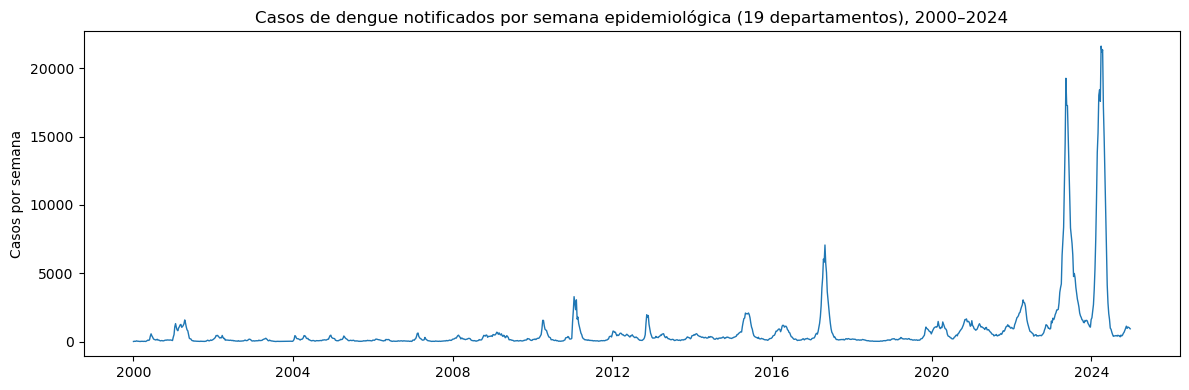

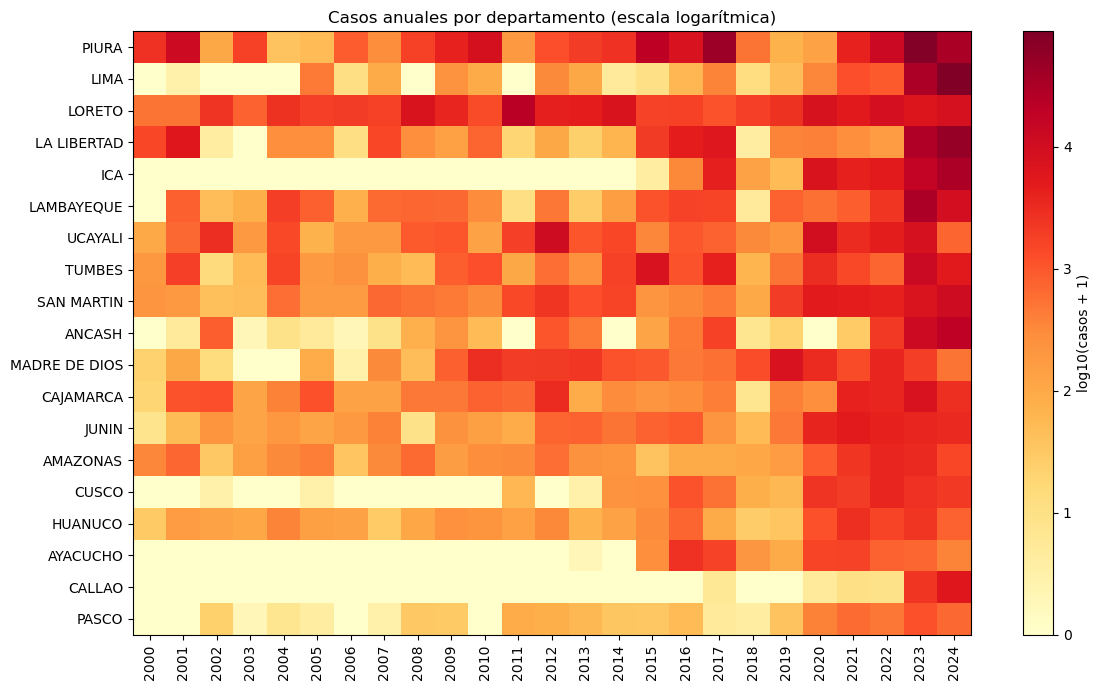

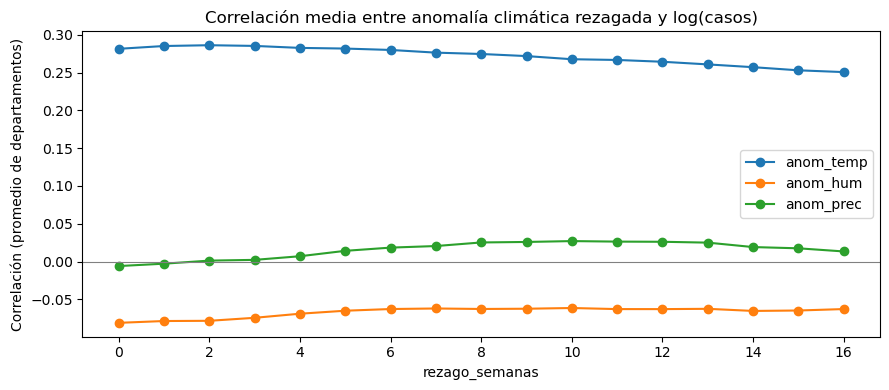

In [4]:
pdf = (panel.select("cod_dep", "departamento", "ano", "semana", "casos", "log_casos",
                    "anom_temp", "anom_hum", "anom_prec").toPandas())   # ~25 000 filas: cabe en memoria
pdf["fecha"] = pd.to_datetime([inicio_anio_epi(a) + timedelta(weeks=s - 1)
                               for a, s in zip(pdf["ano"], pdf["semana"])])
pdf = pdf.sort_values(["cod_dep", "ano", "semana"])

# Figura 1 — ¿Cuándo ocurren las epidemias?
nacional = pdf.groupby("fecha")["casos"].sum()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(nacional.index, nacional.values, linewidth=1)
ax.set_title("Casos de dengue notificados por semana epidemiológica (19 departamentos), 2000–2024")
ax.set_ylabel("Casos por semana")
fig.tight_layout(); fig.savefig(dir_fig / "fig1_serie_nacional.png", dpi=150); plt.show()

# Figura 2 — ¿Dónde se concentra el dengue y cómo ha cambiado?
matriz = pdf.pivot_table(index="departamento", columns="ano", values="casos", aggfunc="sum")
matriz = matriz.loc[matriz.sum(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(np.log10(matriz + 1), aspect="auto", cmap="YlOrRd")
ax.set_yticks(range(len(matriz.index))); ax.set_yticklabels(matriz.index)
ax.set_xticks(range(len(matriz.columns))); ax.set_xticklabels(matriz.columns, rotation=90)
ax.set_title("Casos anuales por departamento (escala logarítmica)")
fig.colorbar(im, label="log10(casos + 1)")
fig.tight_layout(); fig.savefig(dir_fig / "fig2_mapa_calor.png", dpi=150); plt.show()

# Figura 3 — ¿Con cuántas semanas de anticipación se asocia el clima con los casos?
filas = []
for k in range(0, 17):
    fila = {"rezago_semanas": k}
    for v in ["anom_temp", "anom_hum", "anom_prec"]:
        fila[v] = pdf.groupby("cod_dep").apply(
            lambda g: g["log_casos"].corr(g[v].shift(k))).mean()
    filas.append(fila)
cc = pd.DataFrame(filas).set_index("rezago_semanas")
ax = cc.plot(marker="o", figsize=(9, 4))
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_title("Correlación media entre anomalía climática rezagada y log(casos)")
ax.set_ylabel("Correlación (promedio de departamentos)")
plt.tight_layout(); plt.savefig(dir_fig / "fig3_correlacion_rezagos.png", dpi=150); plt.show()

In [5]:
datos = panel.filter(F.col("label").isNotNull()).dropna(subset=VARS_CASOS + VARS_CLIMA)
train = datos.filter(F.col("ano").between(*ANIOS_TRAIN))
test = datos.filter(F.col("ano").between(*ANIOS_TEST)).cache()

p = train.agg(F.avg("label")).first()[0]
train = train.withColumn("peso", F.when(F.col("label") == 1, 0.5 / p).otherwise(0.5 / (1 - p)))
print(f"Train: {train.count()} filas, {p:.1%} positivas | Test: {test.count()} filas, "
      f"{test.agg(F.avg('label')).first()[0]:.1%} positivas")

def entrenar(variables):
    return Pipeline(stages=[
        VectorAssembler(inputCols=variables, outputCol="x"),
        StandardScaler(inputCol="x", outputCol="features"),
        LogisticRegression(featuresCol="features", labelCol="label", weightCol="peso", maxIter=100),
    ]).fit(train)

def metricas(pred, col_score, umbral=0.5):
    ev = lambda m: BinaryClassificationEvaluator(labelCol="label", rawPredictionCol=col_score,
                                                 metricName=m).evaluate(pred)
    c = (pred.withColumn("yhat", (F.col(col_score) >= umbral).cast("double"))
             .agg(*[F.sum(((F.col("yhat") == a) & (F.col("label") == b)).cast("int")).alias(n)
                    for n, a, b in [("vp", 1, 1), ("fp", 1, 0), ("fn", 0, 1), ("vn", 0, 0)]])
             .first())
    return {"AUC_ROC": round(ev("areaUnderROC"), 3), "AUC_PR": round(ev("areaUnderPR"), 3),
            "precision": round(c.vp / (c.vp + c.fp), 3) if c.vp + c.fp else None,
            "recall": round(c.vp / (c.vp + c.fn), 3) if c.vp + c.fn else None,
            "VP": c.vp, "FP": c.fp, "FN": c.fn, "VN": c.vn}

resultados = [{"modelo": "Persistencia: 'si hoy hay brote, habrá brote'",
               **metricas(test, "brote_actual")}]
modelos = {}
for nombre, variables in {"Logística: solo historial de casos": VARS_CASOS,
                          "Logística: casos + clima (LÍNEA BASE)": VARS_CASOS + VARS_CLIMA}.items():
    modelos[nombre] = entrenar(variables)
    pred = modelos[nombre].transform(test).withColumn("prob", vector_to_array("probability")[1])
    resultados.append({"modelo": nombre, **metricas(pred, "prob")})

tabla = pd.DataFrame(resultados)
display(tabla)
tabla.to_csv(dir_met / "modelo_base.csv", index=False)

lr = modelos["Logística: casos + clima (LÍNEA BASE)"].stages[-1]
coef = pd.Series(lr.coefficients.toArray(), index=VARS_CASOS + VARS_CLIMA).sort_values()
display(coef.round(3).to_frame("coeficiente (variables estandarizadas)"))

Train: 14858 filas, 30.4% positivas | Test: 3876 filas, 67.2% positivas


,modelo,AUC_ROC,AUC_PR,precision,recall,VP,FP,FN,VN
0,"Persistencia: 'si hoy hay brote, habrá brote'",0.886,0.942,0.968,0.828,2157,72,449,1198
1,Logística: solo historial de casos,0.928,0.964,0.796,0.955,2490,637,116,633
2,Logística: casos + clima (LÍNEA BASE),0.922,0.962,0.782,0.958,2496,695,110,575


,coeficiente (variables estandarizadas)
anom_hum_4_7,-0.145
anom_hum_8_11,-0.054
anom_temp_4_7,0.007
anom_prec_0_3,0.032
anom_prec_8_11,0.043
anom_temp_8_11,0.062
anom_prec_4_7,0.102
anom_temp_0_3,0.162
anom_hum_0_3,0.188
log_casos_l1,0.666
